<a href="https://colab.research.google.com/github/oluchiokoro-debug/colab-git-assignment2-OO/blob/main/titanic_eda_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
import os
import requests # Added import for requests

file_name = "Titanic-Dataset.csv"
if not os.path.exists(file_name):
    # Public URL for a Titanic dataset
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    print(f"Downloading {file_name} from {url}...")
    try:
        response = requests.get(url)
        response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
        with open(file_name, "wb") as f:
            f.write(response.content)
        print(f"Successfully downloaded {file_name}.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
        print("Please ensure you have an internet connection or upload 'Titanic-Dataset.csv' manually.")
        # Re-raise the original FileNotFoundError or handle it gracefully
        raise FileNotFoundError(f"Could not find or download '{file_name}'.")

df = pd.read_csv(file_name)

df.head()

Successfully downloaded Titanic-Dataset.csv.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df["Pclass_cat"] = df["Pclass"].map({1: "First", 2: "Second", 3: "Third"})

df["Cabin"] = df["Cabin"].fillna("Unknown")
df["Cabin_cat"] = df["Cabin"].apply(lambda x: x[0] if x != "Unknown" else "U")

In [9]:
df["Age"].fillna(df["Age"].median(), inplace=True)

/tmp/ipykernel_1270/2097741607.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)


In [10]:
df[df["Fare"] == df["Fare"].max()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_cat,Cabin_cat
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,Unknown,C,First,U
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,First,B
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,First,B


In [12]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df[df["FamilySize"] == df["FamilySize"].max()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_cat,Cabin_cat,FamilySize
159,160,0,3,"Sage, Master. Thomas Henry",male,28.0,8,2,CA. 2343,69.55,Unknown,S,Third,U,11
180,181,0,3,"Sage, Miss. Constance Gladys",female,28.0,8,2,CA. 2343,69.55,Unknown,S,Third,U,11
201,202,0,3,"Sage, Mr. Frederick",male,28.0,8,2,CA. 2343,69.55,Unknown,S,Third,U,11
324,325,0,3,"Sage, Mr. George John Jr",male,28.0,8,2,CA. 2343,69.55,Unknown,S,Third,U,11
792,793,0,3,"Sage, Miss. Stella Anna",female,28.0,8,2,CA. 2343,69.55,Unknown,S,Third,U,11
846,847,0,3,"Sage, Mr. Douglas Bullen",male,28.0,8,2,CA. 2343,69.55,Unknown,S,Third,U,11
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,28.0,8,2,CA. 2343,69.55,Unknown,S,Third,U,11


In [13]:
age_series = df["Age"]
print(age_series.head())

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64


In [14]:
df[["Name", "Age", "Fare"]].head()

,Name,Age,Fare
0,"Braund, Mr. Owen Harris",22.0,7.2500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,71.2833
2,"Heikkinen, Miss. Laina",26.0,7.9250
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,53.1000
4,"Allen, Mr. William Henry",35.0,8.0500


In [15]:
df.loc[0:5, ["Name", "Survived", "Age"]]
df.iloc[0:5, 0:5]

,PassengerId,Survived,Pclass,Name,Sex
0,1,0,3,"Braund, Mr. Owen Harris",male
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female
2,3,1,3,"Heikkinen, Miss. Laina",female
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female
4,5,0,3,"Allen, Mr. William Henry",male


In [16]:
multi = df.groupby(["Sex", "Pclass"])["Survived"].mean().unstack()
multi

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


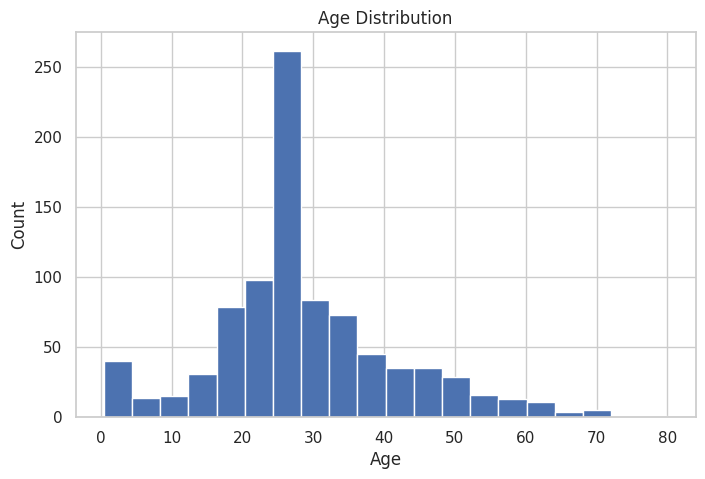

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

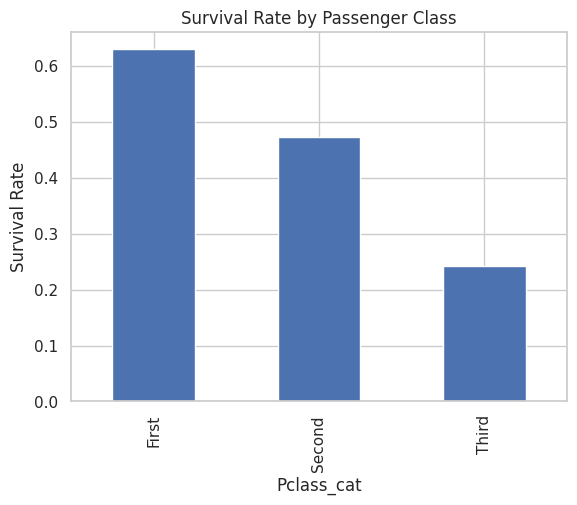

In [18]:
survival_by_class = df.groupby("Pclass_cat")["Survived"].mean()

survival_by_class.plot(kind="bar")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

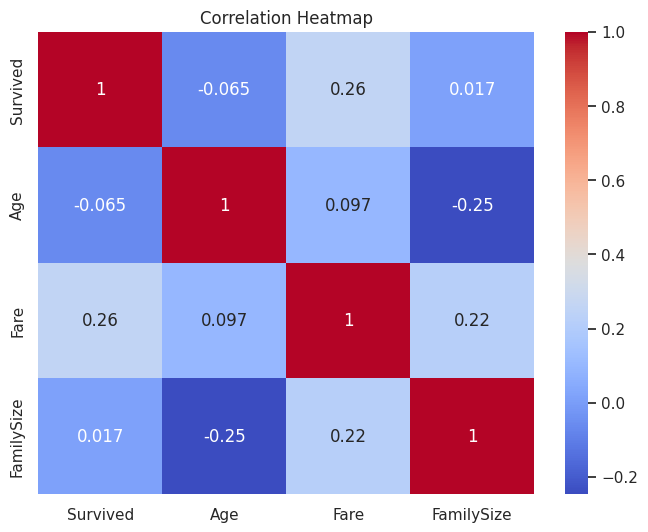

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["Survived","Age","Fare","FamilySize"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

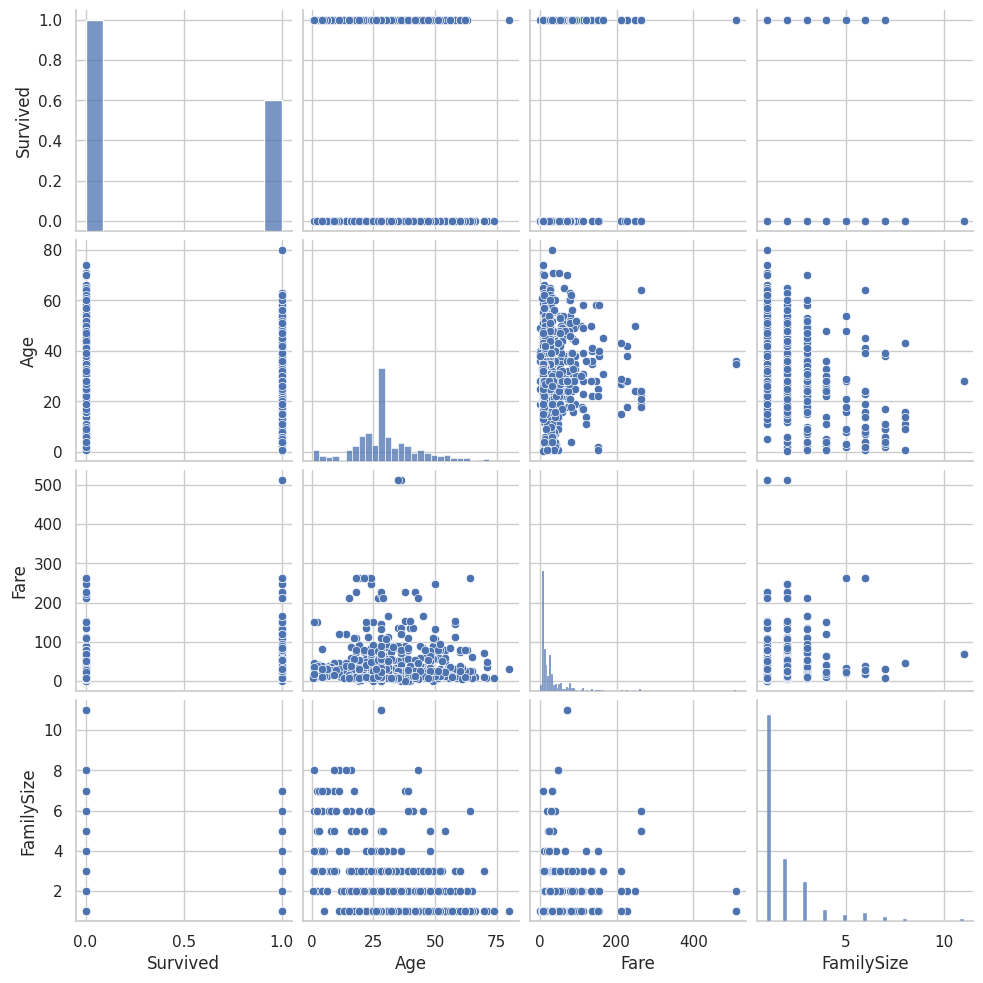

In [20]:
sns.pairplot(df[["Survived","Age","Fare","FamilySize"]])
plt.show()

In [21]:
df.groupby(["Sex","Pclass"])["Survived"].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

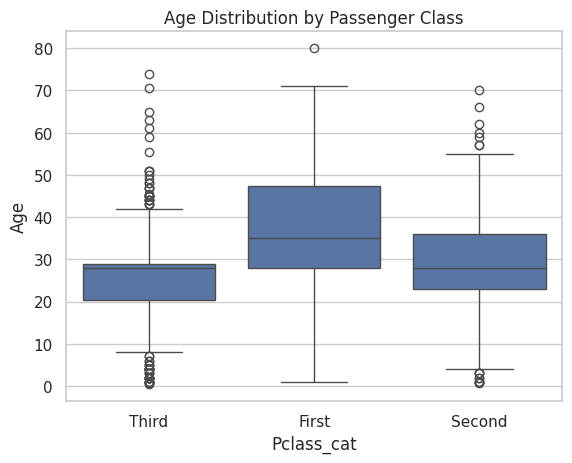

In [22]:
sns.boxplot(x="Pclass_cat", y="Age", data=df)
plt.title("Age Distribution by Passenger Class")
plt.show()

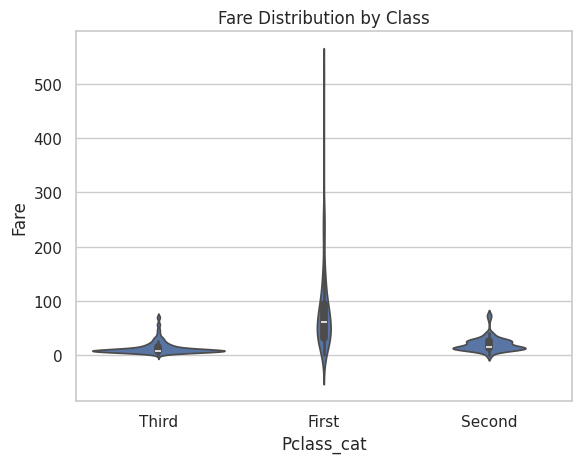

In [23]:
sns.violinplot(x="Pclass_cat", y="Fare", data=df)
plt.title("Fare Distribution by Class")
plt.show()

In [24]:
plt.figure(figsize=(12, 6))
# plt.title('Fare Distribution by Passenger Class and Survival Status')
# plt.show()

print("EDA tasks completed.")

EDA tasks completed.


<Figure size 1200x600 with 0 Axes>